In [111]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


In [112]:
def load_usb_csv(csv_path: Path) -> np.ndarray:
    data = np.loadtxt(csv_path, delimiter=",", skiprows=1)
    if data.ndim == 1:
        data = data[:, np.newaxis]
    return data.astype(np.float64)

In [113]:
calib_path = Path("run_2_calib.csv")
press_path_2 = Path("run_2_press_2_small.csv")
press_path_1 = Path("run_2_press_1_small.csv")
press_path_3 = Path("run_2_press_3_small.csv")
press_path_4 = Path("run_2_press.csv")
press_path_5 = Path("run_2_press_2.csv")


calib_data = load_usb_csv(calib_path)
press_data = load_usb_csv(press_path_2)
press_data_1 = load_usb_csv(press_path_1)
press_data_3 = load_usb_csv(press_path_3)
press_data_4 = load_usb_csv(press_path_4)
press_data_5 = load_usb_csv(press_path_5)
print("Calibration Data Shape:", calib_data.shape)
print("Press Data Shape:", press_data.shape)

calib_data = calib_data * (3.3 / 4095)  # convert to voltage
press_data = press_data * (3.3 / 4095)  # convert to voltage
press_data_1 = press_data_1 * (3.3 / 4095)  # convert to voltage
press_data_3 = press_data_3 * (3.3 / 4095)
press_data_4 = press_data_4 * (3.3 / 4095)  # convert to voltage
press_data_5 = press_data_5 * (3.3 / 4095)

time = np.arange(len(calib_data)) * (1/6.25)  # time vector based on sampling rate


Calibration Data Shape: (766, 1000)
Press Data Shape: (766, 1000)


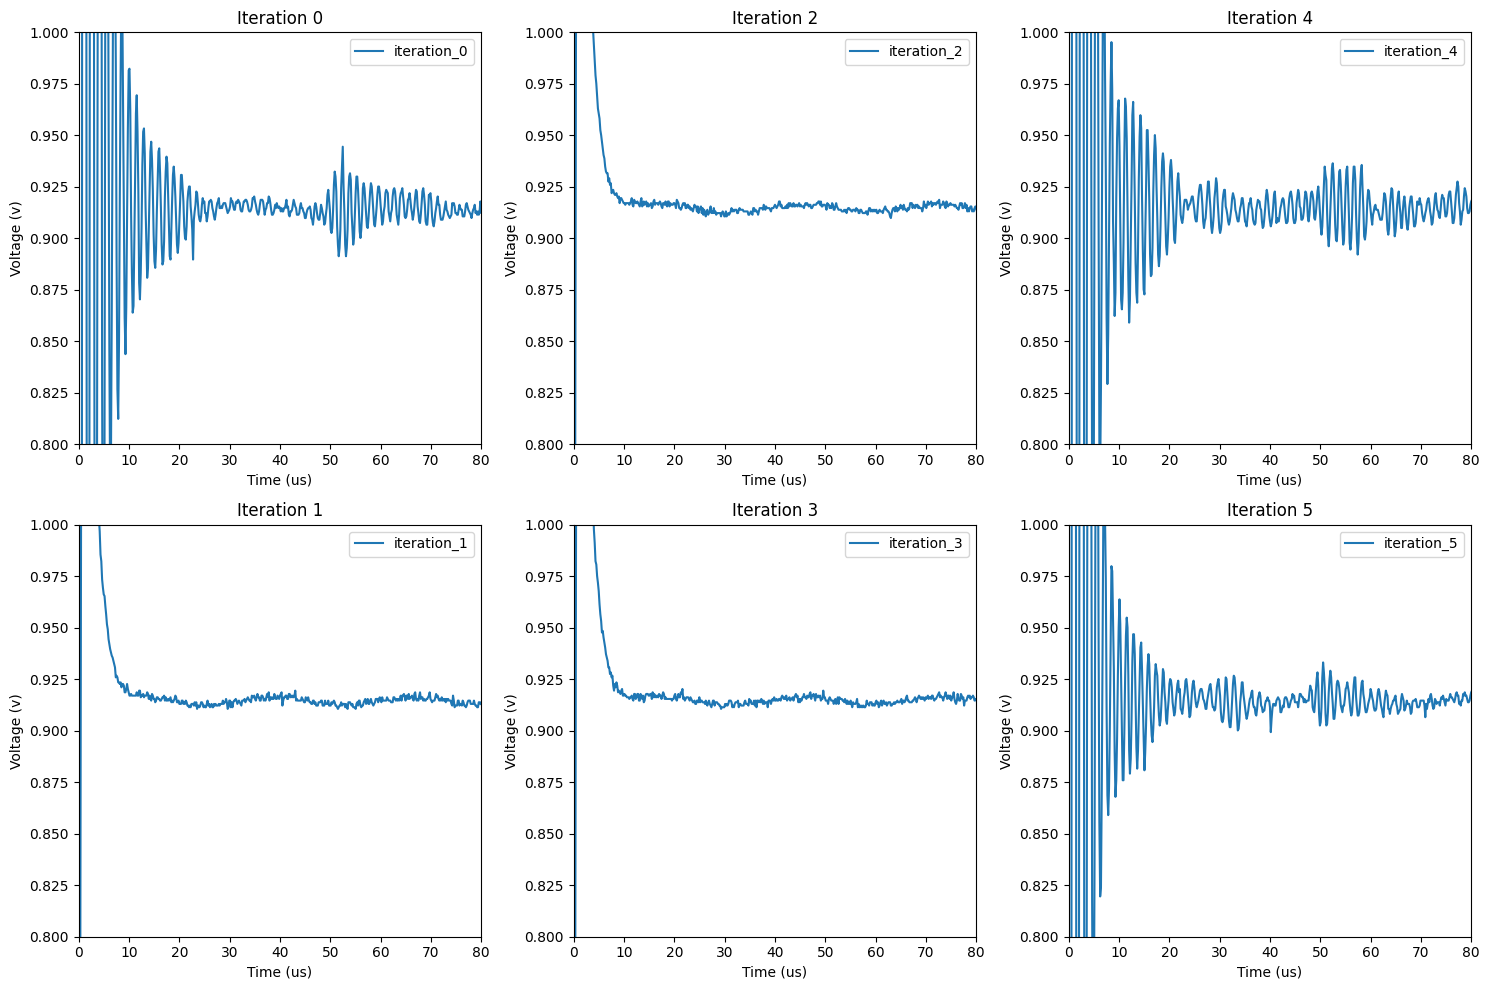

In [114]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for i in range(6):  
    row, col = i % 2, i // 2
    axs[row, col].plot(time, calib_data[:,i+18], label=f'iteration_{i}')
    axs[row, col].set_title(f'Iteration {i}')
    axs[row, col].set_xlabel('Time (us)')
    axs[row, col].set_ylabel('Voltage (v)')
    axs[row, col].legend()
    axs[row, col].set_ylim(0.8, 1.0)  # set y-axis limits for better visualization
    axs[row, col].set_xlim(0, 80)  # set x-axis limits for better visualization
plt.tight_layout()
plt.show()

Expected edge time: 44.17 us
Expected press edge time: 20.70 us


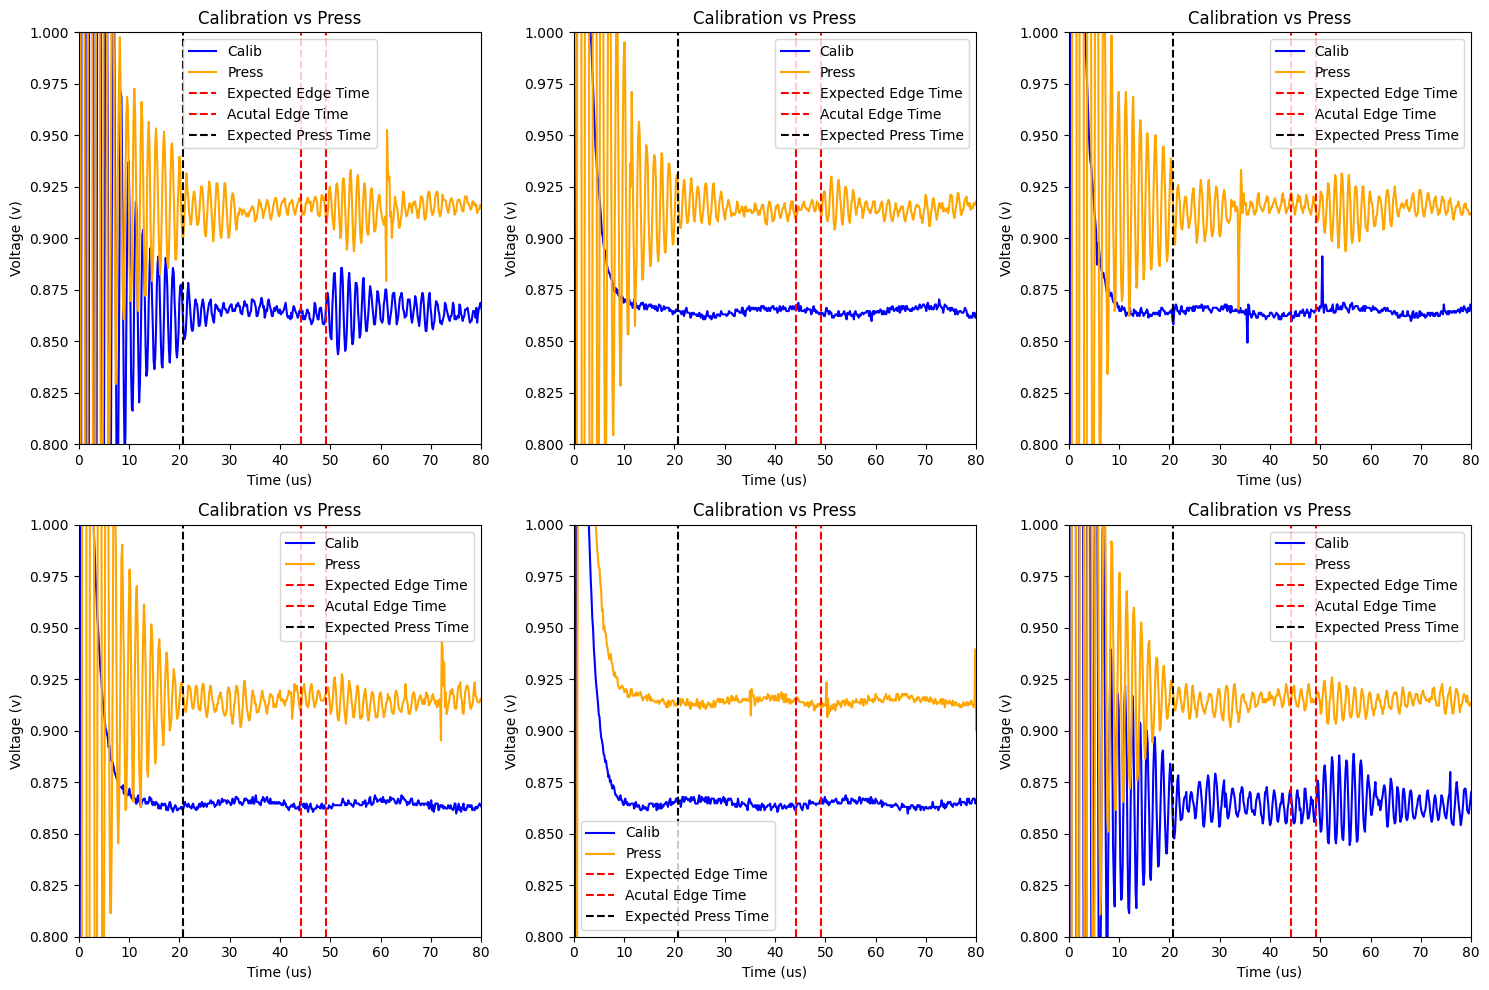

In [115]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
offset = 30
file_offset = 1

c = 1449
# c = 1540
l = 0.032 
l_press = 0.015

edge_time = 2 * l / c * 1e6 # in microseconds
press_edge_time = 2 * l_press / c * 1e6 # in microseconds
print(f"Expected edge time: {edge_time:.2f} us")
print(f"Expected press edge time: {press_edge_time:.2f} us")


for i in range(6):  
    row, col = i % 2, i // 2
    axs[row, col].plot(time, calib_data[:,i+offset] - 0.05, label=f'Calib', color='blue')
    axs[row, col].plot(time, press_data[:,i+offset+file_offset], label=f'Press', color='orange')
    axs[row, col].set_title(f'Calibration vs Press')
    axs[row, col].set_xlabel('Time (us)')
    axs[row, col].set_ylabel('Voltage (v)')
    axs[row, col].set_ylim(0.8, 1.0)  # set y-axis limits for better visualization
    axs[row, col].set_xlim(0, 80)  # set x-axis limits for better visualization
    axs[row, col].axvline(x=edge_time, color='red', linestyle='--', label='Expected Edge Time')
    axs[row, col].axvline(x=edge_time + 5, color='red', linestyle='--', label='Acutal Edge Time')
    axs[row, col].axvline(x=press_edge_time, color='black', linestyle='--', label='Expected Press Time')

    axs[row, col].legend()

plt.tight_layout()
plt.show()

#18


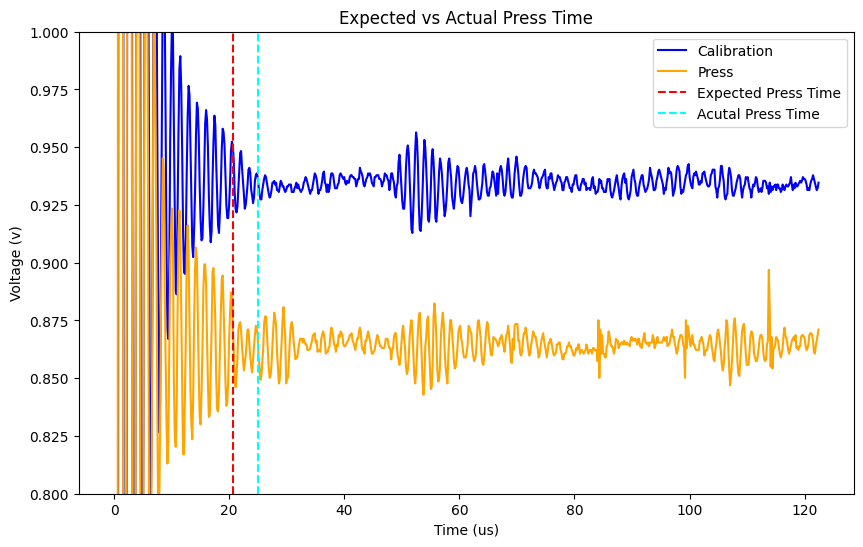

In [116]:
calib = calib_data[:, 1]
press = press_data[:, 1]


plt.figure(figsize=(10, 6))
plt.plot(time, calib + 0.02, label='Calibration', color='blue')
plt.plot(time, press - 0.05, label='Press', color='orange')
# plt.plot(time, shifted_press, label='Press', color='orange')
plt.title('Expected vs Actual Press Time')  
# plt.title('Calibration vs Press Data')  
# plt.legend()
plt.xlabel('Time (us)')
plt.ylabel('Voltage (v)')
plt.axvline(x=press_edge_time, color='red', linestyle='--', label='Expected Press Time')
plt.axvline(x=25, color='cyan', linestyle='--', label='Acutal Press Time')
# plt.xlim(0, 80)  # set x-axis limits for better visualization
plt.ylim(0.8, 1.0)  # set y-axis limits
plt.legend()
plt.show()

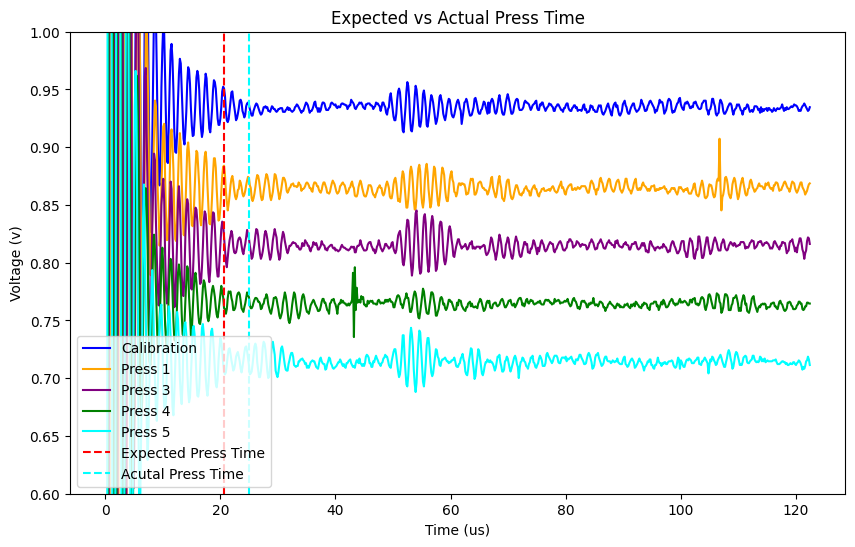

In [122]:
# plot calibration and press data press_1 and press_3
calib = calib_data[:, 1]
press_1 = press_data_1[:, 5]
press_3 = press_data_3[:, 3]
press_4 = press_data_4[:, 2]
press_5 = press_data_5[:, 5]

plt.figure(figsize=(10, 6))
plt.plot(time, calib + 0.02, label='Calibration', color='blue')
plt.plot(time, press_1 - 0.05, label='Press 1', color='orange')
plt.plot(time, press_3 - 0.1, label='Press 3', color='purple')
plt.plot(time, press_4 - 0.15, label='Press 4', color='green')
plt.plot(time, press_5 - 0.2, label='Press 5', color='cyan')
plt.title('Expected vs Actual Press Time')
plt.xlabel('Time (us)')
plt.ylabel('Voltage (v)')
plt.axvline(x=press_edge_time, color='red', linestyle='--', label='Expected Press Time')
plt.axvline(x=25, color='cyan', linestyle='--', label='Acutal Press Time')
plt.ylim(0.6, 1.0)  # set y-axis limits
plt.legend()
plt.show()

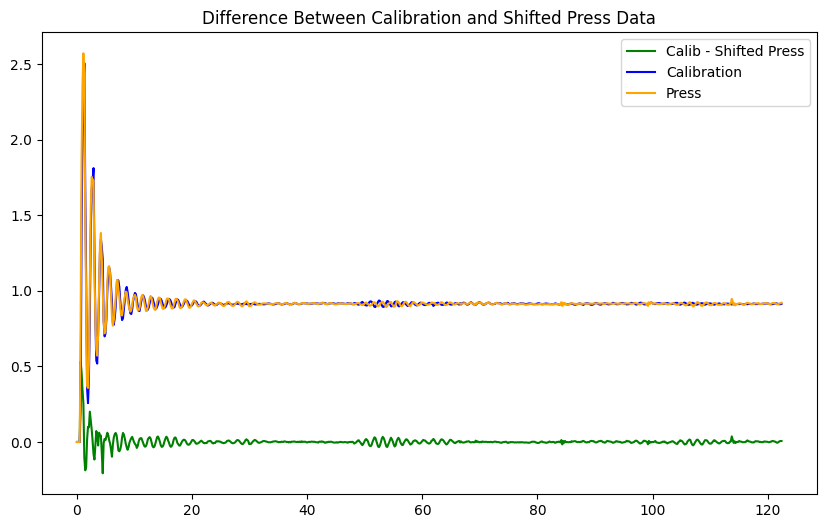

In [118]:
phase_shift = 0  # example phase shift in seconds

# shift press data by phase shift
shifted_press = np.roll(press, phase_shift)
# subtract press from calib
diff = shifted_press - calib
# diff = calib - shifted_press

plt.figure(figsize=(10, 6))
plt.plot(time, diff, label='Calib - Shifted Press', color='green')
plt.plot(time, calib, label='Calibration', color='blue')
plt.plot(time, shifted_press, label='Press', color='orange')
plt.title('Difference Between Calibration and Shifted Press Data')
plt.legend()
plt.show()